### Titanic dataset kaggle competition
question: “what sorts of people were more likely to survive?”

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [30]:
df = pd.read_csv('data/train_titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: >

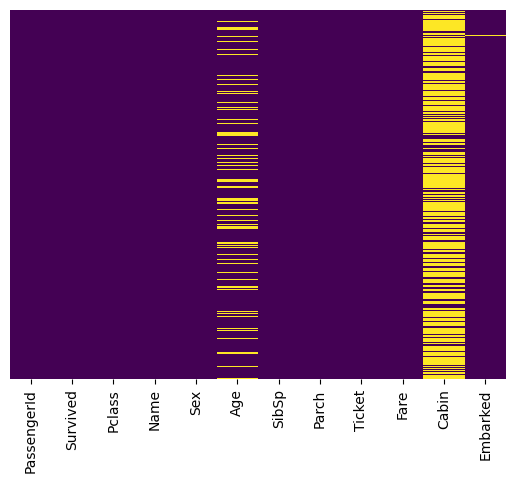

In [32]:
sns.heatmap(df.isnull(),yticklabels = False,cbar = False,cmap = 'viridis')

#### Data cleaning

In [33]:
df.drop('Cabin',axis = 1,inplace = True)

<Axes: >

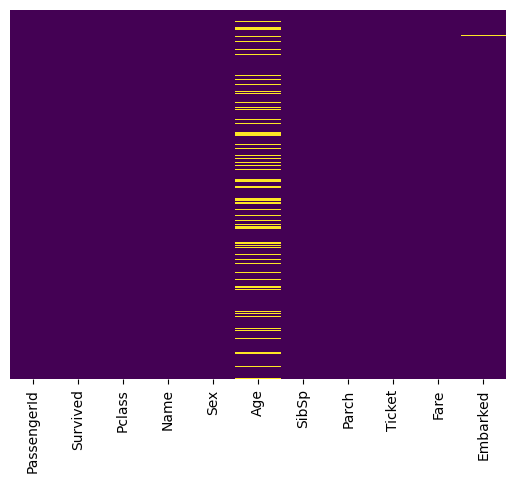

In [34]:
sns.heatmap(df.isnull(),yticklabels = False,cbar = False,cmap = 'viridis')

C:\Users\megha\AppData\Local\Temp\ipykernel_7324\514439688.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y = 'Age',x = 'Pclass',data = df,palette = 'winter')


<Axes: xlabel='Pclass', ylabel='Age'>

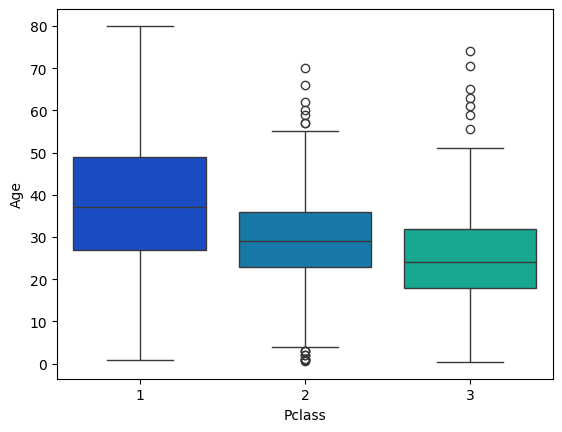

In [35]:
sns.boxplot(y = 'Age',x = 'Pclass',data = df,palette = 'winter')

In [36]:
#function to impute the average age based on the Pclass
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        if Pclass == 2:
            return 29
        if Pclass == 3:
            return 24
    else:
        return Age

In [37]:
df['Age'] = df[['Age','Pclass']].apply(impute_age,axis =1)

C:\Users\megha\AppData\Local\Temp\ipykernel_7324\3089410132.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\megha\AppData\Local\Temp\ipykernel_7324\3089410132.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


<Axes: >

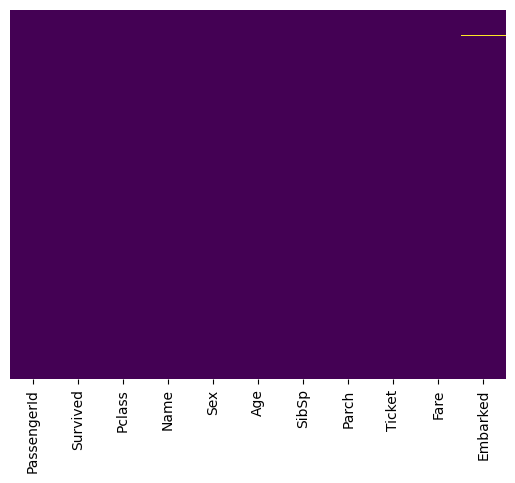

In [38]:
sns.heatmap(df.isnull(),yticklabels = False,cbar = False,cmap = 'viridis')

#### Converting the categorical features

In [39]:
sex = pd.get_dummies(df['Sex'],drop_first = True)
embark = pd.get_dummies(df['Embarked'],drop_first = True)

In [40]:
df.drop(['Sex','Embarked','Name','Ticket'],axis = 1,inplace = True)
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [41]:
df = pd.concat([df,sex,embark],axis=1)
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


### Building the logistic regression model

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score

In [43]:
x = df.drop('Survived',axis = 1)
y = df['Survived']

In [44]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state =101 )

In [45]:
logmodel = LogisticRegression()
logmodel.fit(x_train,y_train)


c:\Users\megha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
predictions = logmodel.predict(x_test)

In [50]:
confusion_matx = confusion_matrix(y_test,predictions)
confusion_matx

array([[134,  20],
       [ 42,  72]])

In [51]:
accuracy_score(y_test,predictions)

0.7686567164179104

### Building random forest model

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
predictions_rf = rf.predict(x_test)
accuracy_score(y_test,predictions_rf)


0.8208955223880597

there is a score improvement 

* logistic regression(76.86%) 
* random forest(82%)

#### Building XGboost model

In [55]:
import xgboost as xgb

In [56]:
model = xgb.XGBClassifier(n_estimators = 100,
                          learning_rate = 0.1,
                          max_depth = 5,
                          use_label_encoder = False,
                          eval_metric = 'logloss'
                          )
model.fit(x_train,y_train)

c:\Users\megha\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


,objective,'binary:logistic'
,use_label_encoder,False
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [57]:
predictions_xg = model.predict(x_test)
accuracy_score(y_test,predictions_xg)

0.8134328358208955

#### let's try on the whole train and test datasets

In [81]:
#importing the test dataset
df1 = pd.read_csv('data/test_titanic.csv')
df1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [82]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   male         891 non-null    bool   
 7   Q            891 non-null    bool   
 8   S            891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


In [83]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


<Axes: >

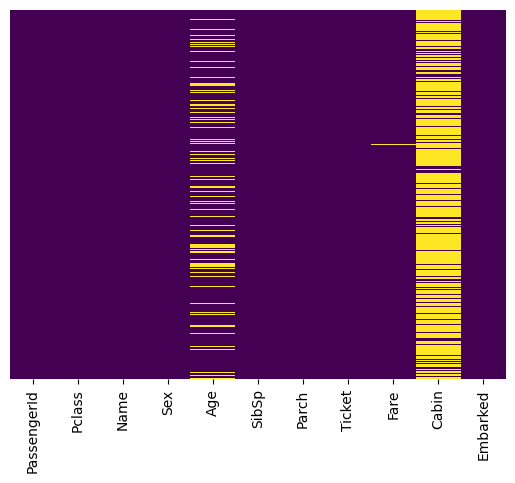

In [84]:
sns.heatmap(df1.isnull(),cmap = 'viridis',cbar = False,yticklabels = False)

In [85]:
df1.drop('Cabin',axis = 1,inplace = True)

In [86]:
df1['Age'] = df1[['Age','Pclass']].apply(impute_age,axis = 1)

C:\Users\megha\AppData\Local\Temp\ipykernel_7324\3089410132.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\megha\AppData\Local\Temp\ipykernel_7324\3089410132.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


<Axes: >

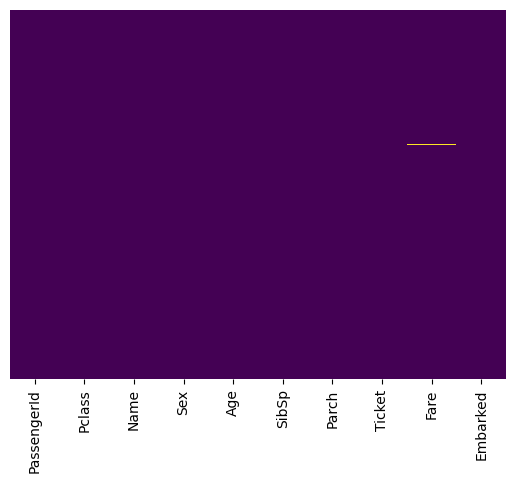

In [87]:
sns.heatmap(df1.isnull(),yticklabels = False,cbar = False,cmap = 'viridis')

In [88]:
#converting the categorical variables
sex=pd.get_dummies(df1['Sex'],drop_first = True)
embark = pd.get_dummies(df1['Embarked'],drop_first = True)


In [89]:
df1.drop(['Sex','Embarked','Name','Ticket'],axis = 1,inplace = True)
df1.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
0,892,3,34.5,0,0,7.8292
1,893,3,47.0,1,0,7.0000
2,894,2,62.0,0,0,9.6875
3,895,3,27.0,0,0,8.6625
4,896,3,22.0,1,1,12.2875


In [90]:
df1 = pd.concat([df1,sex,embark],axis = 1)

In [91]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Age          418 non-null    float64
 3   SibSp        418 non-null    int64  
 4   Parch        418 non-null    int64  
 5   Fare         417 non-null    float64
 6   male         418 non-null    bool   
 7   Q            418 non-null    bool   
 8   S            418 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 20.9 KB


In [92]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   male         891 non-null    bool   
 7   Q            891 non-null    bool   
 8   S            891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


In [101]:
#using random forest on whole train and test datasets
real_predictions = rf.predict(df1)

# Create the submission file
import pandas as pd
submission = pd.DataFrame({
    "PassengerId": df1['PassengerId'], # You should have saved these earlier
    "Survived": real_predictions
})

submission.to_csv('data/meg_kaggle_submission_rf.csv', index=False)

In [100]:
#using xgboost fore predictions
# Make sure 'test_df' has the exact same columns/preprocessing as your train_df!
real_predictions = model.predict(df1)

# Create the submission file
import pandas as pd
submission = pd.DataFrame({
    "PassengerId": df1['PassengerId'], # You should have saved these earlier
    "Survived": real_predictions
})

submission.to_csv('data/meg_kaggle_submission.csv', index=False)

#### Building using ANN

In [102]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Dense

In [103]:
from tensorflow.keras.callbacks import EarlyStopping

# Initialize the callback
early_stop = EarlyStopping(
    monitor='val_loss',     # Watch the validation loss
    mode='min',              # We want to minimize loss
    patience=10,             # How many epochs to wait after the last improvement
    verbose=1,               # Let us know when it stops
    restore_best_weights=True # Very important: rolls back to the best version
)

In [ ]:
model_ANN = Sequential()
model_ANN.add(Dense(units=16, activation='relu', input_dim=x_train.shape[1]))
model_ANN.add(Dropout(0.2))
model_ANN.add(Dense(units = 8,activation = 'relu'))
model_ANN.add(Dense(units=1, activation='sigmoid'))
model_ANN.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Train the ANN
model_ANN.fit(x_train, y_train, batch_size=32, epochs=600, validation_split=0.2,callbacks=[early_stop])

c:\Users\megha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/600
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.4218 - loss: 18.3572 - val_accuracy: 0.3040 - val_loss: 2.1218
Epoch 2/600
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5116 - loss: 8.5710 - val_accuracy: 0.6880 - val_loss: 4.4582
Epoch 3/600
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5168 - loss: 8.6006 - val_accuracy: 0.6880 - val_loss: 5.6175
Epoch 4/600
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5977 - loss: 6.6342 - val_accuracy: 0.6960 - val_loss: 5.1539
Epoch 5/600
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5162 - loss: 7.2804 - val_accuracy: 0.6720 - val_loss: 4.5258
Epoch 6/600
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5615 - loss: 5.0067 - val_accuracy: 0.6480 - val_loss: 3.2936
Epoch 7/600
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4725 - loss: 5.3274 - val_accuracy: 0.6080 - val_loss: 2.3626
Epoch 8/600
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4909 - loss: 4.1327 - val_accuracy: 0.

In [111]:
# Make sure you are using the variable name for your 418-row test set
final_probs = model_ANN.predict(df1)
final_predictions = (final_probs > 0.5).astype("int32")

print(len(final_predictions))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
418


In [116]:
submission = pd.DataFrame({
    "PassengerId": df1['PassengerId'],
    "Survived": final_predictions.flatten() # Flatten to make it a 1D array
})

submission.to_csv('data/titanic_ann_submission_ANN.csv', index=False)